In [1]:
### Imports
from time import thread_time_ns
import numpy as np
from pathlib import Path
import random
import itertools
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
import json
import math
import pprint
import pandas as pd
from time import thread_time_ns
from datetime import datetime
import statistics
from collections import defaultdict
import colorsys
from dataclasses import dataclass
from itertools import combinations
from math import hypot



Find the centers - our current pipeline

In [2]:
def detection(thresholds,blob_params, gray):
    detector = cv.SimpleBlobDetector_create(blob_params)
    centers= []
    for thresh in thresholds:
        _, thresholded = cv.threshold(gray, thresh, 255, cv.THRESH_BINARY)
        keypoints = detector.detect(thresholded)
        current_centers = [(round(kp.pt[0]), round(kp.pt[1])) for kp in keypoints]
        new_centers = []
        for curr_center in current_centers:
            isNew = True
            for c in centers:
                    distance = math.dist(curr_center, c)
                    isNew = distance >= 10
                    if not isNew:
                        break
            if isNew:
                new_centers.append(curr_center)
        centers = centers + new_centers
    return centers


def blobParamFunc(minArea, minCircularity):
    params = cv.SimpleBlobDetector_Params()
    params.filterByCircularity = True
    params.minCircularity = minCircularity
    params.minArea=minArea
    params.blobColor = 0
    return params

def findCenters(file_path):
    image = cv.imread(file_path, cv.IMREAD_COLOR_RGB)
    imageBlurred = cv.medianBlur(image, 3)
    gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
    thresholds = np.arange(160,190,10)
    blob_params = blobParamFunc(400, .8)
    point_list = detection(thresholds=thresholds, blob_params= blob_params, gray=gray)
    return (point_list,image)
     

Find the pixels around the center, block of 2xside by 2xside around that center, so side up and side down etc
side = 25, block of 50 by 50.
Return a list of pairs of the block and the x and y that it's around

Get the colors at each coordinate, and color correct them against the white that is in the corners of the image.

Clamp Function based on the Paper Programs clamping.

In [3]:
def clamp(value, lowerbound, upperbound):
    if value < lowerbound:
        return lowerbound
    elif value > upperbound:
        return upperbound
    return value

In [4]:
def getColorCoords(point_list, side, image):
    def getDotList(point_list, side, image):
        dot_list = []
        for pt in point_list:
            x,y= pt
            crop_img = image[clamp(y-side, 0, image.shape[0]):clamp(y+side, 0, image.shape[0]), 
                             clamp(x-side, 0, image.shape[1]): clamp(x+side, 0, image.shape[1])]
            dot_list.append((crop_img, (x,y)))
        return dot_list

    dot_list = getDotList(point_list, side, image)

    colorCoords = []
    for dot_pair in dot_list:
        dot = dot_pair[0]
        # plt.imshow(dot)
        x,y = dot_pair[1]
        maxPixel = (side*2)-1
        points = [dot[0,maxPixel],dot[maxPixel,0],dot[0,maxPixel],dot[maxPixel,maxPixel]]
        baselineWhite = [max([points[i][0] for i in range(0,4)]),
                        max([points[i][1] for i in range(0,4)]),
                        max([points[i][2] for i in range(0,4)])]
        circleColor = image[y,x]
        new = [round(circleColor[0]/baselineWhite[0]*255),
               round(circleColor[1]/baselineWhite[1]*255),
               round(circleColor[2]/baselineWhite[2]*255)]
        colorCoords.append((dot_pair[1], new))
    return colorCoords

Find the dot closest to black in the dot list. Do this by converting to HSV and finding the darkest valued dot.

In [5]:
def getBlackDot(colorCoords):
    colorCoords_hsv = []
    for c in colorCoords:
        colorCoords_hsv.append((c[0],colorsys.rgb_to_hsv(c[1][0]/255, c[1][1]/255,c[1][2]/255)))
    values = [hsv[1][2] for hsv in colorCoords_hsv]
    blackDot = (colorCoords[values.index(min(values))])
    return blackDot

Class for point manipulation.

In [6]:
@dataclass
class Point:
    x: float = 0.0
    y: float = 0.0

    @classmethod
    def from_tuple(cls, coords):
        return cls(coords[0], coords[1])

    def as_tuple(self):
        return (self.x, self.y)


Functions for finding points and their distances between each other

In [7]:

def bucket(value: float, size: float):
    # print(value, int(value / size))
    return int(value / size)

def euc_dist(a: Point, b: Point) -> float:
    return hypot(b.x - a.x, b.y - a.y)

def same_midpoint(pairA, pairB, threshold=20):
    # note - threshold is in pixels
    def midpoint(pair):
        a, b = pair
        return Point((b.x - a.x) / 2.0, (b.y - a.y) / 2.0)

    # compute the midpoints of each pair
    midA = midpoint(pairA)
    midB = midpoint(pairB)

    # are they the same? or rather are they some delta distant
    distance = euc_dist(midA, midB)

    return distance < threshold


def point_as_ints(point):
    return int(point[0]), int(point[1])

Gets all possible rectangles based on the points given

In [8]:
def get_all_rects(point_list):
    pointified = [Point.from_tuple(pt) for pt in point_list]
    pairs = list(combinations(pointified, 2))
    bucketed = [bucket(round(euc_dist(a, b)), 100) for a, b in pairs]
    tally = defaultdict(list)
    for pair, dist in zip(pairs, bucketed):
        tally[dist].append(pair)
    same_distance_pairs = dict(((dist, pairs) for dist, pairs in tally.items() if len(pairs) > 1))
    all_rects = []
    for _, pairs in same_distance_pairs.items():
        pairs_of_pairs = combinations(pairs, 2)
        rects = [(p1, p2) for (p1, p2) in pairs_of_pairs if same_midpoint(p1, p2)]
        all_rects.extend(rects)
    return all_rects

Find any duplicate rectangles and get rid of them. (this happens because two sets of parellel lines, so two possible iterations of the same rectangle are often found)

In [9]:

def checkRects(all_rects):
    checked = []
    for rect in all_rects:
        p0, p2 = rect[0]
        p1, p3 = rect[1]
        rect_point_list = [p0, p2, p1, p3]
        target = Point(0,0)
        rect_point_list.sort(key= lambda p: euc_dist(p, target))
        if rect_point_list not in checked:
            checked.append(rect_point_list)
    return checked

Orders the points (alone) clockwise from the black dot.

A function to show the rectangles found on the image given.

In [10]:

def displayFoundRect(rect, image):
    out = image.copy()
    p0,p1,p2,p3 = convertRectToList(rect)

    cv.line(out, p0, p2, (255, 0, 0), 10)
    cv.line(out, p0, p1, (255, 0, 0), 10)
    cv.line(out, p3, p1, (255, 0, 0), 10)
    cv.line(out, p3, p2, (255, 0, 0), 10)

    plt.imshow(out)
    plt.show()



A dictionary of the RGB values of the color palette.

In [11]:
true_colors_custom = {(253, 22, 34):'a',
                      (254, 0, 255):'b',
                      (0, 254,22): 'c',
                      (0, 132, 254): 'd',
                      (254, 170, 13): 'e',
                      (219, 79, 137): 'f',
                      (235,251, 38): 'g',
                      (0, 248, 196): 'h'}


In [12]:
def easyConvertRGB2LUV(rgb):
        rgb1 = np.array([rgb[0], rgb[1], rgb[2]],dtype=np.uint8) # yellow
        rgb1 = rgb1.reshape((1,1,3))
        luv = cv.cvtColor(rgb1,cv.COLOR_RGB2Luv)[:,0][0]
        return (int(luv[0]), int(luv[1]), int(luv[2])) if(type(rgb)==tuple) else luv

luv_colors_custom ={}
for k, i in true_colors_custom.items():
    luv_colors_custom.update({easyConvertRGB2LUV(k): i})

In [13]:
from PIL import Image
rgb = [202, 52, 47]
def cmykConverter(rgb):
    k = 1 - (max(rgb)/255)
    c = (1 - (rgb[0]/255)-k)/(1-k)
    m = (1 - (rgb[1]/255)-k)/(1-k)
    y = (1 - (rgb[2]/255)-k)/(1-k)
    return (round(c,3),round(m,3),round(y,3),round(k,3)) if type(rgb)==tuple else [round(c,3),round(m,3),round(y,3),round(k,3)]

cmykConverter(rgb)

[0.0, 0.743, 0.767, 0.208]

In [14]:
def easyConvertRGB2CMYK(rgb):
        rgb1 = np.array([rgb[0], rgb[1], rgb[2]],dtype=np.uint8) # yellow
        rgb1 = rgb1.reshape((1,1,3))
        luv = cv.cvtColor(rgb1,cv.COLOR_RGB2)[:,0][0]
        return (int(luv[0]), int(luv[1]), int(luv[2])) if(type(rgb)==tuple) else luv

Uses the point ordering to order the coordinates with their colors

In [ ]:
def orderedPermutation(black_dot, dots):
    ## black dot has the coordinates for the black dot
    if black_dot not in dots:
        print("Black Dot Not in Dots given, something is wrong!")
    dots.remove(black_dot)
    black_dot_distances = [(math.dist(black_dot,d),d)for d in dots]
    black_dot_distances.sort(key= lambda p: p[0])
    ordered = [black_dot_distances[0][1], black_dot_distances[2][1],black_dot_distances[1][1]]
    return ordered

In [15]:
def orderedColors(checked, colorCoords, blackDot):
    def orderedPermutation(black_dot, dots):
        ## black dot has the coordinates for the black dot
        if black_dot not in dots:
            print("Black Dot Not in Dots given, something is wrong!")
        dots.remove(black_dot)
        black_dot_distances = [(math.dist(black_dot,d),d)for d in dots]
        black_dot_distances.sort(key= lambda p: p[0])
        ordered = [black_dot_distances[0][1], black_dot_distances[2][1],black_dot_distances[1][1]]
        return ordered

    def getPerm(checked, blackDot):
        for rect in checked:
            p0, p1, p2, p3 = rect
            perm_list = [p0.as_tuple(), p2.as_tuple(), p1.as_tuple(), p3.as_tuple()]
            ordered = orderedPermutation(blackDot[0], perm_list)
            return (ordered)
        
    ordered = getPerm(checked, blackDot)
    orderedColorCoords = []
    for i in range(len(ordered)):
        for pair in colorCoords:
            if pair[0] == ordered[i]:
                orderedColorCoords.append(pair[1])
    return orderedColorCoords


Uses dictionary of True colors to find the closest color to the given ordered color

In [16]:
def getColorPerm(orderedColors, trueColors):
    true_colors_custom_keys = trueColors.keys()
    perm = ""
    for col in orderedColors:
        diff = 1000
        correct = ''
        for k in true_colors_custom_keys:
            # k_hsv = colorsys.rgb_to_hsv(k[0]/255, k[1]/255,k[2]/255)
            # col_hsv = colorsys.rgb_to_hsv(col[0]/255, col[1]/255,col[2]/255)
            k_cmyk = cmykConverter(k)
            col_cmyk = cmykConverter(col)
            print(f"K in cmyk is {k_cmyk}")
            print(f"Col in cmyk is {col_cmyk}")
            # print(f"K is {k}")
            # print(f"K is {k_hsv}")
            # print(f"Col HSV is {col_hsv}")
            # print(f"col is {col}")
            # new_diff = abs(k[0]-col[0]) +  abs(k[1]-col[1])  + abs(k[2]-col[2])
            # new_luv_diff= sum([abs(int(k_luv[0])-int(col_luv[0])) ,  abs(int(k_luv[1])-int(col_luv[1]))  , abs(int(k_luv[2])-int(col_luv[2]))])
            new_luv_diff= sum([abs((k_cmyk[0])-(col_cmyk[0])) ,  abs((k_cmyk[1])-(col_cmyk[1]))  , abs((k_cmyk[2])-(col_cmyk[2]))])
            print(f"The summed difference between {k_cmyk}, and {col_cmyk} is "+str(new_luv_diff) +"\n") 
            if new_luv_diff < diff:
                diff = new_luv_diff
                # print(new_diff)
                correct = trueColors.get(k)
                # print(k)
                print(f"the closest correct is {correct}")
        perm += correct
    return (perm)

In [17]:
# detection
#centers(path)

# using the centers to get the rectangles
def findRectangles(centers):
    all_rects_new= (get_all_rects(centers)) ## gets all possible rectangles
    checked = (checkRects(all_rects_new)) ## deletes duplicates
    return checked ## this is a list with sets of 4 points that represent the rectangles found

# finding out the dot colors
def findDotColors(centers,image,block_size):
    new_color_coords = getColorCoords(centers,block_size,image)
    blackDot = getBlackDot(new_color_coords)
    return (blackDot, new_color_coords)


#getting the permutation of the rectangle, based on the dot color
def findPermutsRects(checked,new_color_coords, blackDot,true_colors):
    ordered_colors = orderedColors(checked, new_color_coords, blackDot)
    return getColorPerm(ordered_colors, true_colors) # takes the order of the colors, and the dictionary and finds the closes ones.
    

In [18]:
def convertRectToList(rect):
    p0, p1, p2, p3 = rect
    p0, p2, p1, p3 = p0.as_tuple(), p2.as_tuple(), p1.as_tuple(), p3.as_tuple()
    return [point_as_ints(p) for p in [p0, p2, p1, p3]]


In [19]:
def showBlobs(new_color_coords, img,side):
    imgset = []
    for c in new_color_coords:
        x,y = c[0]
        print(c)
        imgset.append(img[clamp(y-side, 0, img.shape[0]):clamp(y+side, 0, img.shape[0]), 
                             clamp(x-side, 0, img.shape[1]): clamp(x+side, 0, img.shape[1])])
    for i in range(len(imgset)):
        plt.subplot(2, 2, i+1)  # 2 rows, 2 columns, first position
        plt.imshow(imgset[i]) 
    raw_color = [(c[1][0]/255,c[1][1]/255,c[1][2]/255) for c in new_color_coords]
    perm = list(itertools.product([0, 1],repeat = 2))
    fig, axes = plt.subplots( 2, 2 )
    for i in range(len(perm)):
        circle1 = plt.Circle( ( .5, .5 ), .5, color = raw_color[i] )
        axes[perm[i][0],perm[i][1] ].add_patch( circle1 )




In [20]:
def permFinder(path,block_size, true_colors):
    centers,image = findCenters(path)
    checked_rects = findRectangles(centers)
    rectPerms = {}
    for rect in checked_rects:
        displayFoundRect(rect, image)
        rect_list = convertRectToList(rect)
        black_dot, new_color_coords = findDotColors(rect_list,image,block_size)
        showBlobs(new_color_coords,image,25)
        permutation = findPermutsRects(checked_rects,new_color_coords, black_dot,true_colors)
        rectPerms.update({tuple(rect_list):permutation})
    return rectPerms, image





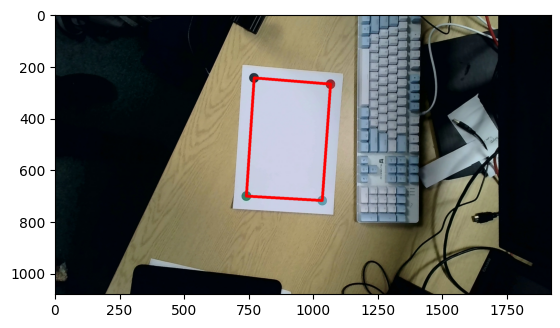

((769, 246), [49, 60, 62])
((1064, 270), [202, 52, 47])
((739, 702), [68, 159, 111])
((1032, 719), [120, 191, 190])
K in cmyk is (0.0, 0.913, 0.866, 0.008)
Col in cmyk is [0.0, 0.743, 0.767, 0.208]
The summed difference between (0.0, 0.913, 0.866, 0.008), and [0.0, 0.743, 0.767, 0.208] is 0.269

the closest correct is a
K in cmyk is (0.004, 1.0, 0.0, 0.0)
Col in cmyk is [0.0, 0.743, 0.767, 0.208]
The summed difference between (0.004, 1.0, 0.0, 0.0), and [0.0, 0.743, 0.767, 0.208] is 1.028

K in cmyk is (1.0, 0.0, 0.913, 0.004)
Col in cmyk is [0.0, 0.743, 0.767, 0.208]
The summed difference between (1.0, 0.0, 0.913, 0.004), and [0.0, 0.743, 0.767, 0.208] is 1.889

K in cmyk is (1.0, 0.48, 0.0, 0.004)
Col in cmyk is [0.0, 0.743, 0.767, 0.208]
The summed difference between (1.0, 0.48, 0.0, 0.004), and [0.0, 0.743, 0.767, 0.208] is 2.0300000000000002

K in cmyk is (0.0, 0.331, 0.949, 0.004)
Col in cmyk is [0.0, 0.743, 0.767, 0.208]
The summed difference between (0.0, 0.331, 0.949, 0.004), 

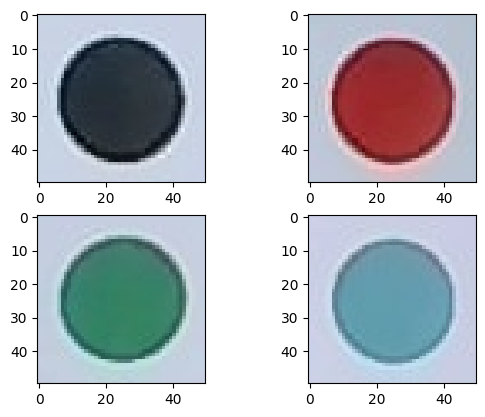

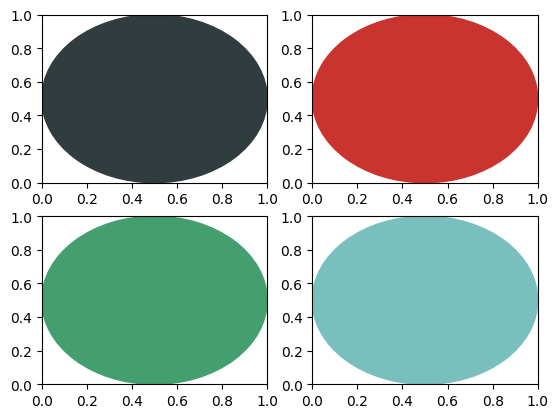

In [21]:
path ="/Users/jdreiling/Desktop/puck/puck/images/custom/john_honey/high/B/custom_john_honey_high_B_4.jpg"
perm, image =(permFinder(path, block_size=25, true_colors=true_colors_custom))
print(perm)

[(929, 663), (1020, 655), (1113, 649), (1013, 564), (1105, 556), (914, 480), (1005, 472), (1097, 464), (921, 571)]


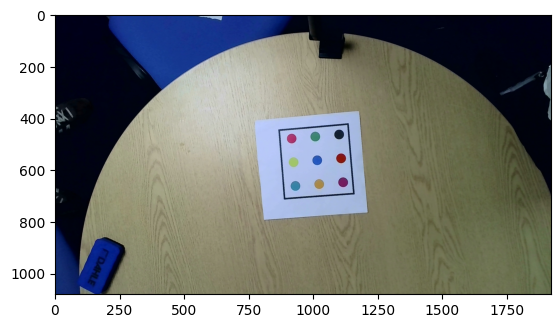

In [24]:
cal_path = "/Users/jdreiling/Desktop/puck/puck/images_calibration/high/custom/davids/high_custom_davids_calibration.jpg"
centers,image = findCenters(cal_path)
print(centers)
plt.imshow(image)

In [33]:
black_dot_coords = findDotColors(centers,image,25)[0][0]


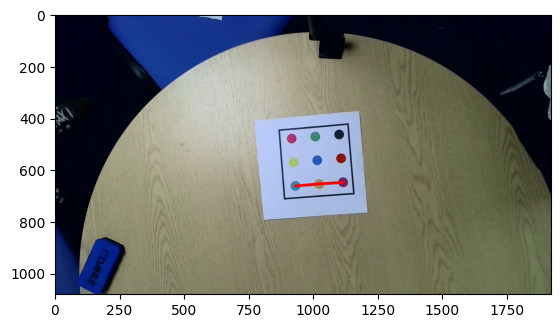

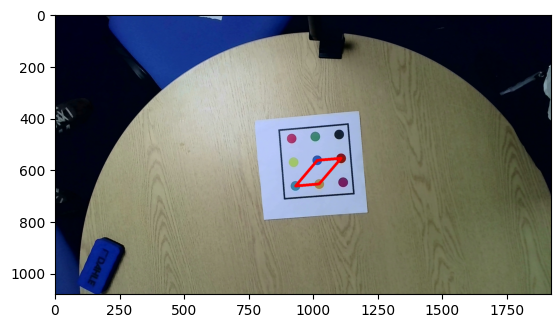

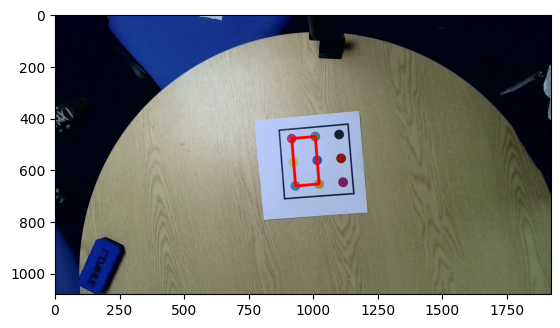

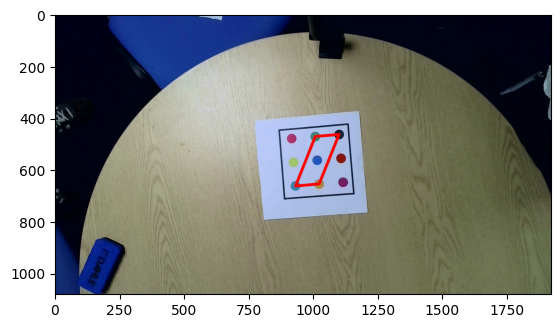

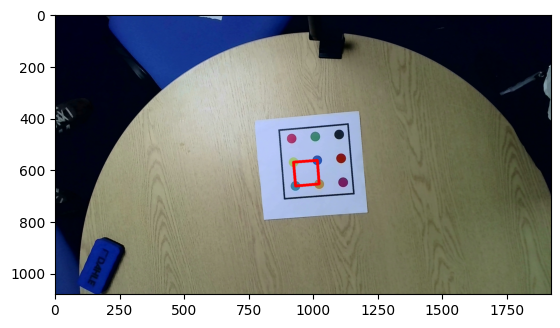

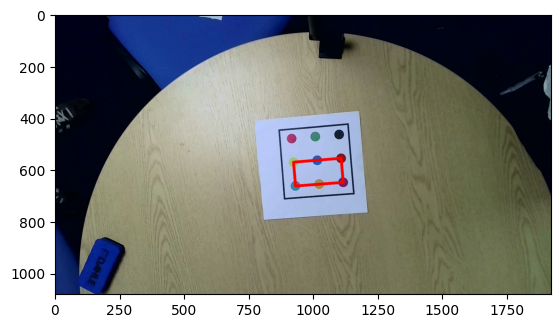

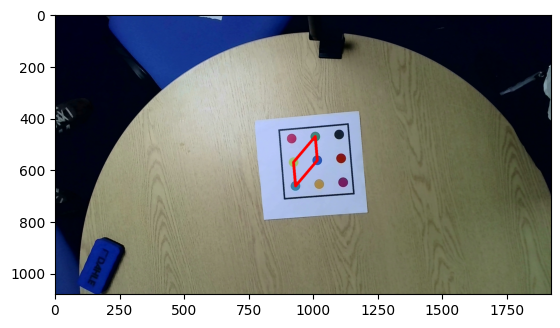

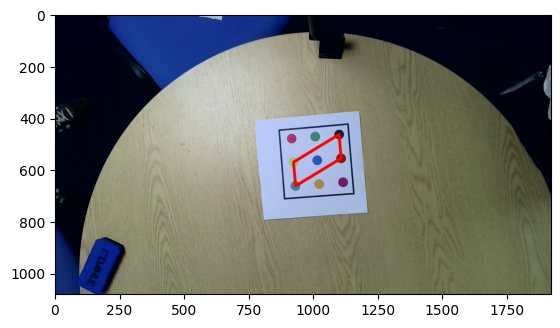

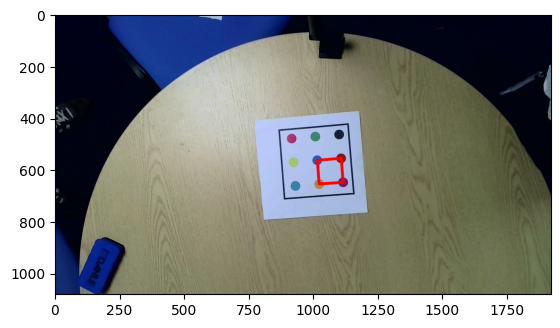

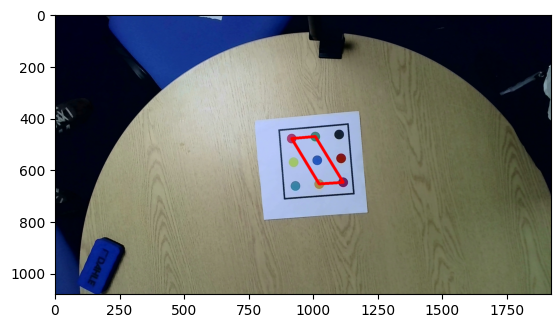

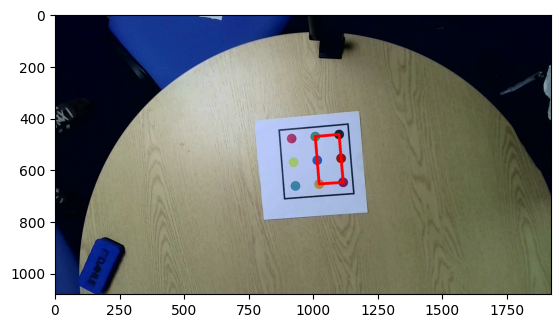

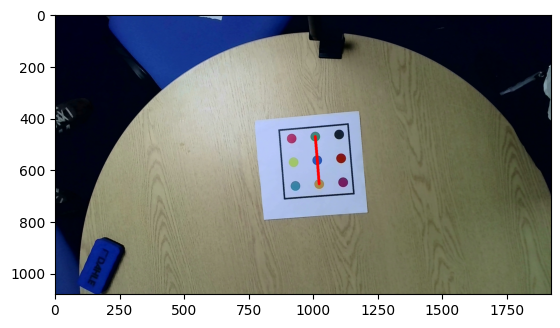

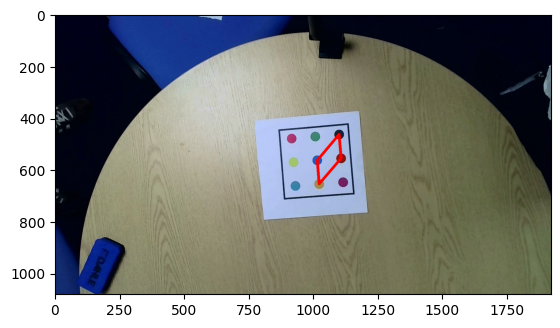

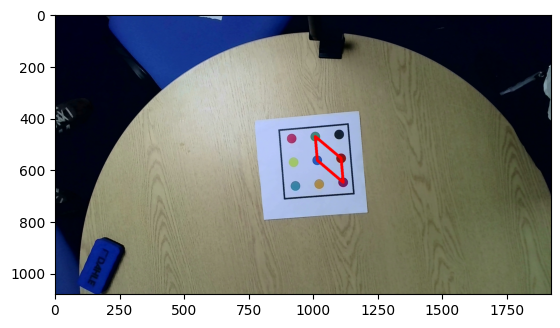

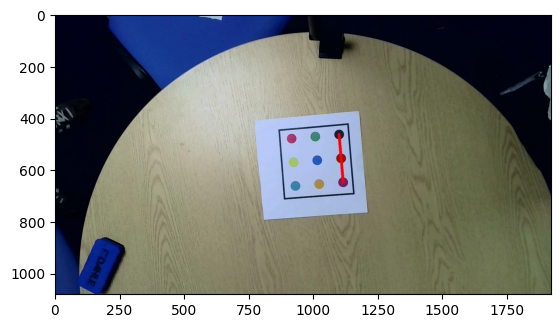

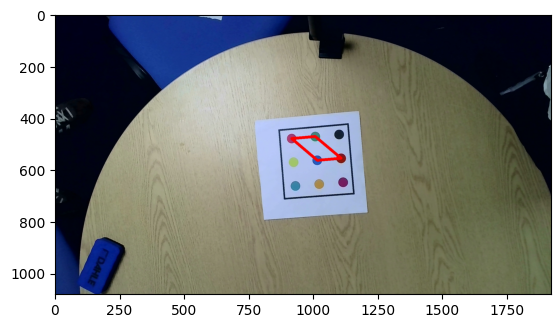

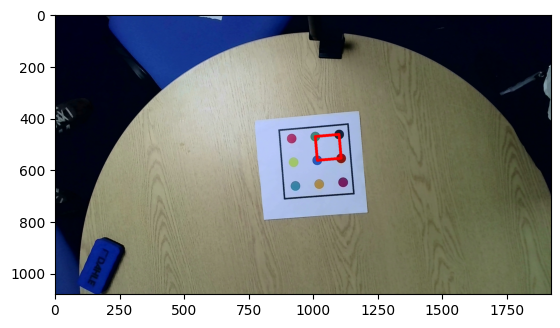

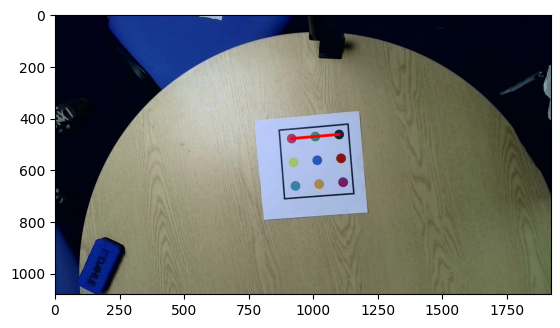

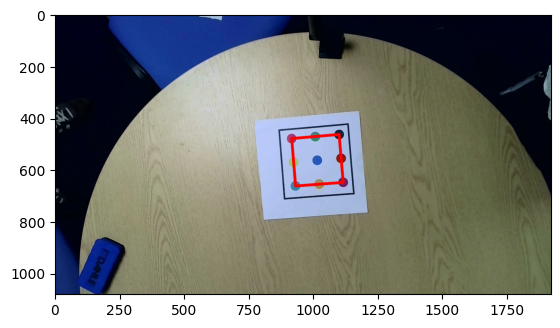

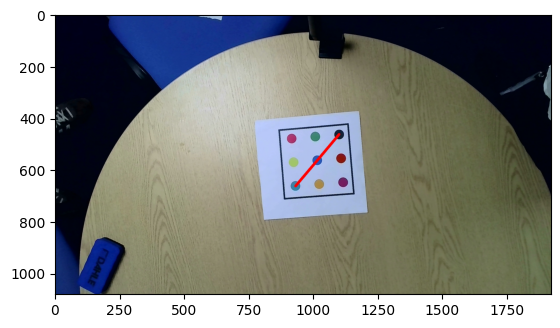

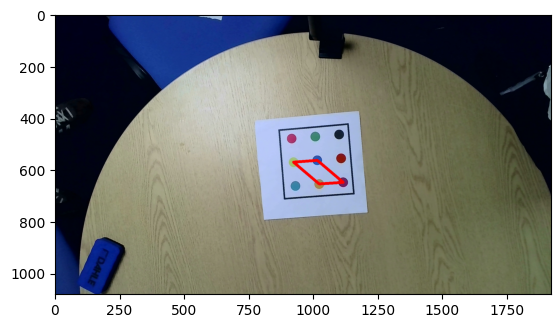

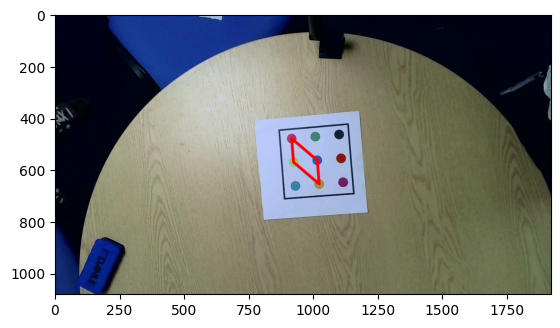

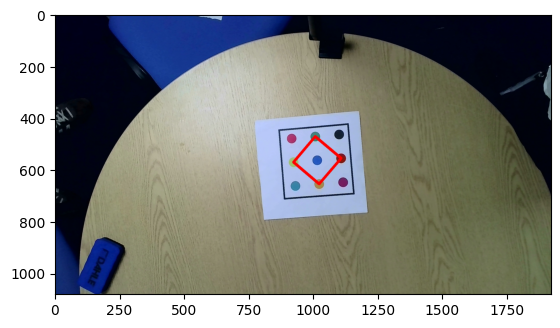

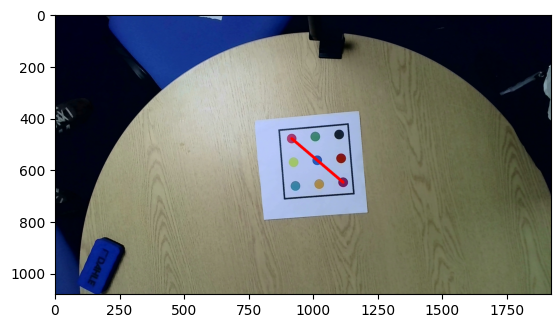

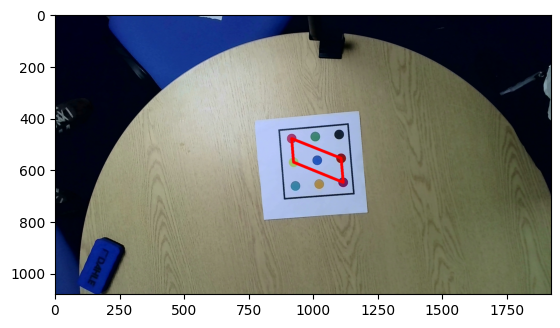

In [29]:
checked_rects = findRectangles(centers)
rectPerms = {}
for rect in checked_rects:
    displayFoundRect(rect, image)

In [66]:

def findSquareswBlackDot(checked_rects, black_dot):
    def recthas(rect, dot):
        return dot in convertRectToList(rect)
    def isSquare(rects):
        best = []
        for r in rects:
            [a,b,c,d] = convertRectToList(r)
            vec_ab= np.array(a)-np.array(b)
            vec_ac = np.array(a)-np.array(c) 
            dist_ab = math.dist(a,b)
            dist_ac = math.dist(a,c)
            dot = np.dot(vec_ab, vec_ac)
            if abs(dot) < 200 and abs(dist_ab- dist_ac) < 20:
                best.append(r)
        return best
    def smallBig(rectList):
        if len(rectList) > 2:
            pass
        rect0 = rectList[0]
        rect1 = rectList[1]
        [a0,b0,_,_] = convertRectToList(rect0)
        [a1,b1,_,_] = convertRectToList(rect1)
        dist0 = math.dist(a0,b0)
        dist1 = math.dist(a1,b1)
        if dist0 > dist1:
            small = rect1
            big = rect0
        else:
            small = rect0
            big = rect1
        return (small,big)

    black_dot_rects =  [rect for rect in checked_rects if recthas(rect,black_dot)]
    return smallBig(isSquare(black_dot_rects))


In [ ]:
black_dot_rects = findSquareswBlackDot(checked_rects,black_dot_coords)
# for rect in black_dot_rects:
#     displayFoundRect(rect, image)
print(black_dot_rects[0]) ## small
print(black_dot_rects[1]) ## big
black_dot_rects_list = list(black_dot_rects)


[Point(x=1005, y=472), Point(x=1013, y=564), Point(x=1097, y=464), Point(x=1105, y=556)]
[Point(x=914, y=480), Point(x=929, y=663), Point(x=1097, y=464), Point(x=1113, y=649)]
Black Dot Not in Dots given, something is wrong!


ValueError: list.remove(x): x not in list

In [ ]:
def identifyColors(small_big, black_dot_coords, centers):
    calibration_dict = {}
    colored_dots = [c for c in centers if c!=black_dot_coords ]
    print(colored_dots)
    print(black_dot_coords)
    small = convertRectToList(small_big[0])
    print(small)
    



identifyColors(black_dot_rects, black_dot_coords, centers)
    

[(929, 663), (1020, 655), (1113, 649), (1013, 564), (1105, 556), (914, 480), (1005, 472), (921, 571)]
(1097, 464)
[(1005, 472), (1097, 464), (1013, 564), (1105, 556)]


In [23]:
"#FD1622",a
"#FE00FF",b
"#00FE16",c
"#0084FE",d 
"#FEAA0D",e
"#DB4F89",f
"#EBFB26",g
"#00F8C4",h


A - '#FD1622', '#0084FE', '#DB4F89' adf
B - '#FD1622', '#00FE16', '#00F8C4' ach
C - '#FEAA0D', '#EBFB26', '#DB4F89' egb
D - '#DB4F89', '#DB4F89', '#DB4F89' fff


SyntaxError: invalid syntax (585755078.py, line 11)

In [ ]:
rgb1 = np.array([251, 230, 38],dtype=np.uint8) # yellow
rgb2 = np.array([170, 13, 254],dtype=np.uint8) # amathyst
rgb1 = rgb1.reshape((1,1,3))
rgb2 = rgb2.reshape((1,1,3))

luvA = cv.cvtColor(rgb1,cv.COLOR_RGB2Luv)
